# 📜 Tabular Classification

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MYTE21/PyTorch/blob/komala/projects/tabular_classification/rice_type_classification.ipynb)

[🔗 Tabular Classification](https://huggingface.co/tasks/tabular-classification) refers to the task of predicting categorical labels based on structured, `tabular data`. This data is organized in `rows (instances)` and `columns (features)`, similar to a spreadsheet or database table.

# 🌾 Rice Type Classification

The [🔗 Rice Type Classification](https://www.kaggle.com/datasets/mssmartypants/rice-type-classification) dataset is a binary classification dataset, where the rice is categorized as either `Jasmine (1)` or `Gonen (0)`. It contains `12 attributes`: ID, Area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRatio, and `Class`. The `Class` attribute represents the `rice type`.

# ⚙️ Imports

Import the necessary libraries and packages.

In [1]:
# Libraries: Standard
import platform
from typing import Tuple
import warnings
warnings.filterwarnings("ignore")

# Libraries: External
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader

# Packages: External
from torchinfo import summary

# Packages: Local
from data import data

# Jupyter Magic Command
%matplotlib inline

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ <code style="color: green">import torch.nn as nn</code> imports the <code>neural network (nn)</code> module from PyTorch, which provides building blocks for <code>creating deep learning models</code>, such as <code>layers</code>, <code>activation functions</code>, and <code>loss functions</code>. ⤴️
</div>

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ <code style="color: green">from torchinfo import summary</code> prints a structured <code>summary of the model</code>, including the number of parameters and layer types. ⤴️
</div>

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Since this is a <code style="color: green">binary classification problem</code>, accuracy is a sufficient metric. However, <code>for multi-class classification</code>, it is highly recommended to use <code>precision</code> and <code>recall</code>, as they provide better insights into specific issues that accuracy alone may not reveal. ⤴️
</div>

# 💻 Setting GPU

Unlike TensorFlow, PyTorch doesn't automatically detect the GPU, so we need to explicitly specify its availability.

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Check PyTorch has access to <a href="https://pytorch.org/get-started/locally/">🔗 MPS (Metal Performance Shader</a>, Apple's GPU architecture). ⤵️
</div>

In [2]:
def get_mps() -> str:
    device_name = "mps" if torch.backends.mps.is_available() else "cpu"
    return device_name

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Check PyTorch has access to <a href="https://developer.nvidia.com/cuda-zone">🔗 CUDA</a>, Nvidia (Windows). ⤵️
</div>

In [3]:
def get_cuda() -> str:
    device_name = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    return device_name

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Set the device. ⤵️
</div>

In [4]:
device = get_mps() if platform.system() == "Darwin" else get_cuda()
print(f"Using device: {device}")

Using device: mps


# 📁 Data
An initial evaluation of the datasets to identify the basics of the data.

## 📂 Load Datasets

In [5]:
df = pd.read_csv(data.get_dataset_path("pytorch-tabular", "raw", "rice_type_classification", 2))

In [6]:
print("Rice type classification Dataset: ")
df.head()

Rice type classification Dataset: 


,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


# 🦊 Data Preprocessing

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Remove rows or columns with missing values. ⤵️
</div>

In [7]:
df.dropna(inplace=True)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Remove the unnecessary id column. ⤵️
</div>

In [8]:
df.drop(["id"], axis=1, inplace=True)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Shape of the modified dataset. ⤵️
</div>

In [9]:
print("Dataset Shape: (row, column):", df.shape)

Dataset Shape: (row, column): (18185, 11)


In [10]:
print("Rice type classification dataset (after dropping unnecessary data): ")
df.head()

Rice type classification dataset (after dropping unnecessary data): 


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [11]:
print("Unique values of the 'Class' column: ", df["Class"].unique())

Unique values of the 'Class' column:  [1 0]


In [12]:
print("Frequency of the 'Class' values: ")
df["Class"].value_counts()

Frequency of the 'Class' values: 


Class
1    9985
0    8200
Name: count, dtype: int64

## 🐣 Normalization

Normalization is the process of scaling or transforming data to fit within a specific range, usually between $0$ and $1$ or $-1$ and $1$. It ensures that all features contribute equally to the model’s performance.

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Copy the original dataset before modification. ⤵️
</div>

In [13]:
original_df = df.copy()

### 🦕 Max Abs Normalization

Scales each feature by its maximum absolute value so that each feature is in the range $[-1, 1]$.

* Formula: $\frac{X}{|X_{max}|}$


In [14]:
for column in df.columns:
    df[column] = df[column] / df[column].abs().max()

In [15]:
print("Dataset after Max Abs Normalization: ")
df.head()

Dataset after Max Abs Normalization: 


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,0.444368,0.503404,0.775435,0.744658,0.424873,0.666610,0.741661,0.537029,0.844997,0.368316,1.0
1,0.281293,0.407681,0.622653,0.750489,0.273892,0.530370,0.804230,0.409661,0.919215,0.371471,1.0
2,0.298531,0.416421,0.630442,0.756341,0.284520,0.546380,0.856278,0.412994,0.959862,0.374747,1.0
3,0.300979,0.420463,0.629049,0.764024,0.286791,0.548616,0.883772,0.414262,0.961818,0.379222,1.0
4,0.361704,0.464626,0.682901,0.775033,0.345385,0.601418,0.867808,0.452954,0.966836,0.386007,1.0


# 🌱 Split Dataset

* Training Size: $70\%$
* Validation Size: $15\%$
* Testing Size: $15\%$

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Separate features (X) and target (y) labels. ⤵️
</div>

In [16]:
X = np.array(df.iloc[:, :-1])
y = np.array(df.iloc[:, -1])

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Split into train ($70\%$) and test ($30\%$). ⤵️
</div>

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Split into test ($15\%$) and validation ($15\%$). ⤵️
</div>

In [18]:
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Shape of the train, validation, and test features dataset. ⤵️
</div>

In [19]:
print("Shape of the train features dataset: ", X_train.shape)
print("Shape of the validation features dataset: ", X_val.shape)
print("Shape of the test features dataset: ", X_test.shape)

Shape of the train features dataset:  (12729, 10)
Shape of the validation features dataset:  (2728, 10)
Shape of the test features dataset:  (2728, 10)


# 🧱 Dataset Object

Convert the dataset to a `PyTorch Dataset object` as it is more efficient during training. (Dataset can be used without creating PyTorch Dataset object)

In [20]:
class TableDataset(Dataset):
    def __init__(self, features: np.float32, target: np.float32) -> None:
        self.feature = torch.tensor(features, dtype=torch.float32).to(device)
        self.target = torch.tensor(target, dtype=torch.float32).to(device)

    def __len__(self) -> int:
        return len(self.feature)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, torch.Tensor]:
        return self.feature[idx], self.target[idx]

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Converted PyTorch Dataset Object. ⤵️
</div>

In [21]:
training_data = TableDataset(X_train, y_train)
validation_data = TableDataset(X_val, y_val)
testing_data = TableDataset(X_test, y_test)

# 🛠️ Hyper Parameters

Hyperparameters are configuration settings that control the learning process. They are not learned from the data but must be manually set before training. Proper tuning of hyperparameters significantly affects model performance.
1. `Batch Size`: Number of samples processed before updating model weights.
    1. *Small Batch: More noise, better generalization.*
    2. *Large Batch: Faster computation, less noise, but may overfit.*
2. `Epochs`: An epoch is one complete pass through the entire training dataset. It defines how many times the model sees the entire dataset during training.
    1. *Too few epochs (underfitting): The model doesn't learn enough patterns.*
    2. *Too many epochs: (Overfitting) The model memorizes the training data and performs poorly on new data.*
3. `Hidden Neurons`: Hidden neurons are the units (nodes) in the hidden layers of a neural network. They help the model learn complex patterns by transforming inputs before passing them to the output layer.
4. `Learning Rate`: The learning rate controls how much the model updates its weights after each batch of training. It is one of the most critical hyperparameters in training deep learning models.
    1. *Too High Learning Rate (0.1 | 1.0): Model diverges, loss fluctuates, unstable training.*
    2. *Too Low Learning Rate (0.000001 | 0.00001): Very slow training; the model might get stuck in local minima.*

In [22]:
BATCH_SIZE = 32
EPOCHS = 10
HIDDEN_NEURONS = 10
LEARNING_RATE = 1e-3

# 📦 Data Loaders

The `DataLoader` class in PyTorch simplifies training by enabling efficient iteration through data in batches. Without batching, the entire dataset is processed at once, which is inefficient. The `DataLoader` allows you to specify a batch size and shuffle data for better training. In the next step, we created `DataLoader` objects for training, validation, and testing datasets to streamline the training process.

In [23]:
training_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
validation_dataloader = DataLoader(validation_data, batch_size=BATCH_SIZE, shuffle=True)
testing_dataloader = DataLoader(testing_data, batch_size=BATCH_SIZE, shuffle=True)

# 🎲 Model Class

The model is defined as a class that inherits from `nn.Module`, allowing customization of functions to fit specific needs. Inside the `__init__` constructor, `super().__init__()` ensures the parent class is properly initialized. The model consists of an `input layer`, a `hidden layer` for feature transformation, and an `output layer` for binary classification, followed by a `sigmoid activation function`. The forward method defines the data flow through these layers.

In [24]:
class Model(nn.Module):
    def __init__(self) -> None:
        super().__init__()
        self.input_layer = nn.Linear(X.shape[1], HIDDEN_NEURONS)
        self.linear = nn.Linear(HIDDEN_NEURONS, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x

# 🥗 Model Creation

We create the model and move it to the assigned device (GPU if available, otherwise CPU). Then, we use the summary function to display the model’s architecture, including its layers and input size.

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Creating model. ⤵️
</div>

In [25]:
model = Model().to(device)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ Summaries of the model. ⤵️
</div>

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ The summary() function from torchinfo moves the model back to the CPU when inspecting it. This is because summary() creates dummy inputs on the CPU by default, and since PyTorch operations are device-sensitive, this can cause issues when the model expects inputs on MPS. ⤵️
</div>

* Solution: To prevent summary() from moving your model back to CPU, explicitly specify the device argument.
```python
summary(\<model\>, (<\columns\>, ), device=device)
```

In [26]:
summary(model, (X.shape[1], ), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
Model                                    [1]                       --
├─Linear: 1-1                            [10]                      110
├─Linear: 1-2                            [1]                       11
├─Sigmoid: 1-3                           [1]                       --
Total params: 121
Trainable params: 121
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

# 🦞 Loss and Optimizer

Create a loss function: `Binary Cross-Entropy` and an optimizer, `Adam`. Adam will take the model parameters/weights and the learning rate.

In [27]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=LEARNING_RATE)

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ <code style="color: green">nn.BCELoss()</code> (Binary Cross-Entropy Loss) is a loss function in PyTorch used for binary classification tasks. It computes the difference between predicted probabilities and actual binary labels. The input to <code>nn.BCELoss()</code> should be a probability (between 0 and 1). ⤴️
</div>

<div style = "border: 2px solid #4B0082; padding: 5px 10px; border-radius: 10px;">
⚓️ <code style="color: green">Adam</code> is an optimization algorithm used in deep learning to update neural network weights efficiently. It combines the benefits of two other optimizers:
<ul>
    <li><strong>Momentum</strong>: Which helps accelerate learning by considering past gradients.</li>
    <li><b>RMSprop</b>: Which adapts the learning rate based on recent gradients. ⤴️</li>
</ul>
</div>

# 🚂 Training and Validation

Now comes the exciting part. As we mentioned several times, nothing is complex here if you know how deep learning works. You just need to know PyTorch syntax. We start by initializing the for loop with the specified number of epochs. But before that we define 4 lists and inside the loop we define another 4 variables.

## Variables:

-   `total_acc_train`: here we will keep tracking of the training accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch.

-   `total_loss_train`: here we will keep tracking of the training loss progress during each epoch, we calculate the accuracy during the batch size and we use the loss value to optimize and modify the model parameters.

-   `total_acc_val`: here we will keep tracking of the validation accuracy progress during each epoch, we calculate the accuracy during the batch size and we print it in the end for tracking the accuracy on each epoch and help us know if there is any overfitting.

-   `total_loss_val`: here we will keep tracking of the validation loss progress during each epoch, we calculate the accuracy during the batch size.


## Lists:

-   `total_acc_train_plot`: We append the losses of the training accuracy to visualize them at the end.

-   `total_loss_train_plot`: We append the losses of the training to visualize them at the end.

-   `total_acc_validation_plot`: We append the losses of the validation accuracy to visualize them at the end.

-   `total_loss_validation_plot`: We append the losses of the validation to visualize them at the end.


## Training

Then, we start to loop through the training dataloaders, we use the enumerate functionality to loop through data and indices at the same time. We are not using the indices here, but lets kept it just if you want to try different stuff with the loop or debug. In the second loop, we start by getting our data from the data loader, then we move the inputs and labels to the cuda device. We allow the model to make a prediction or what is called forward propagation, then we get the output of the model and compare it with our original output using the loss criteration. We use the squeeze function to modify the shape of the output and make it returns a tensor with all specified dimensions of input of size 1 removed. we add the loss amount to  `total_loss_train`. Additionally, we get the accuracy by comparing the correct batch with the predicted batch and we add it to the total_acc_train. Then we do the  `batch_loss.backward()`  which makes the backpropagation and we use the optimizer to do a step on the weights using  `optimizer.step()`  and then we reset the optimizer gradients using  `optimizer.zero_grad()`  which is a very important step that has to be done before proceeding.

## Validation

After that we exit the batch loop (train dataloader loop) and we start with the validation. Don't forget that we are still in the same epoch. In side that we start by with  `torch.no_grad()`  which means that we need the model to do predicitons without being trained. We just need to see the validation preformance. Then we do the same steps which are predicting and calculating loss and accuracy and storing these values.

At the end we print after each epoch the epoch number, training loss, training accuracy, validation loss and validation accuracy. We use the printing of "=" signs just for making the printing output looks clean.

In [28]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

In [29]:
for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_validation = 0
    total_loss_validation = 0

    for data in training_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_train = criterion(prediction, labels)
        total_loss_train += batch_loss_train.item()

        acc = (prediction.round() == labels).sum().item()
        total_acc_train += acc

        batch_loss_train.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data

            prediction = model(inputs).squeeze(1)

            batch_loss_validation = criterion(prediction, labels)
            total_loss_validation += batch_loss_validation.item()

            acc = (prediction.round() == labels).sum().item()
            total_acc_validation += acc

    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_validation/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/len(training_data) * 100, 4))
    total_acc_validation_plot.append(round(total_acc_validation/len(validation_data) * 100, 4))

    print(f"""Epoch no. {epoch + 1} Train Loss: {total_loss_train/1000:.4f} Train Accuracy: {(total_acc_train/(training_data.__len__())*100):.4f} Validation Loss: {total_loss_validation/1000:.4f} Validation Accuracy: {(total_acc_validation/(validation_data.__len__())*100):.4f}""")
    print("="*50)


Epoch no. 1 Train Loss: 0.2331 Train Accuracy: 83.9422 Validation Loss: 0.0369 Validation Accuracy: 95.9677
Epoch no. 2 Train Loss: 0.1130 Train Accuracy: 97.5410 Validation Loss: 0.0154 Validation Accuracy: 98.0205
Epoch no. 3 Train Loss: 0.0534 Train Accuracy: 98.3188 Validation Loss: 0.0089 Validation Accuracy: 97.9106
Epoch no. 4 Train Loss: 0.0338 Train Accuracy: 98.5938 Validation Loss: 0.0065 Validation Accuracy: 98.2038
Epoch no. 5 Train Loss: 0.0259 Train Accuracy: 98.5388 Validation Loss: 0.0056 Validation Accuracy: 97.9839
Epoch no. 6 Train Loss: 0.0219 Train Accuracy: 98.6723 Validation Loss: 0.0049 Validation Accuracy: 98.5704
Epoch no. 7 Train Loss: 0.0197 Train Accuracy: 98.6566 Validation Loss: 0.0045 Validation Accuracy: 98.4971
Epoch no. 8 Train Loss: 0.0182 Train Accuracy: 98.6488 Validation Loss: 0.0043 Validation Accuracy: 98.4238
Epoch no. 9 Train Loss: 0.0176 Train Accuracy: 98.6645 Validation Loss: 0.0040 Validation Accuracy: 98.5704
Epoch no. 10 Train Loss: 0.0

# 🔅 Testing

Now in this section, we will be testing our model, we will start the code by with `torch.no_grad():` which means that we are telling PyTorch that we don't want to train the model we will be using it only for testing. Then we will declare initial loss and accuracy as zeros, we will start by looping through the testing dataloader like we did before during training. Inside the loop, we got our data and we moved it to our GPU (cuda) and then we ran our model on the data and we got the predictions. After that we get the loss and then we add it to our overall loss, we do the same for accuracy, and finally we print the accuracy.

In [30]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0

    for data in testing_dataloader:
        inputs, labels = data

        prediction = model(inputs).squeeze(1)

        batch_loss_test = criterion(prediction, labels)
        total_loss_test += batch_loss_test.item()

        acc = (prediction.round() == labels).sum().item()
        total_acc_test += acc

print(f"Accuracy Score is: {round((total_acc_test/X_test.shape[0])*100, 2)}%")

Accuracy Score is: 98.46%


# 🖼️ Visualization

The results may not be very good, feel free to play with the layers, hyperparameters and text filteration to achieve better performance!

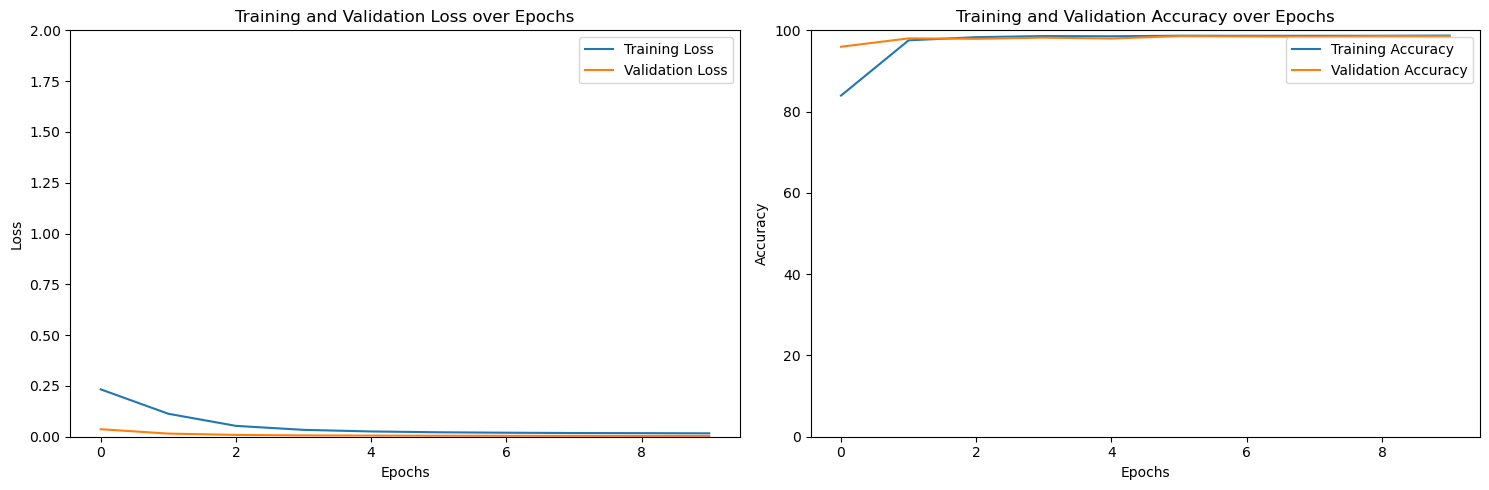

In [31]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_validation_plot, label='Validation Loss')
axs[0].set_title('Training and Validation Loss over Epochs')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')
axs[0].set_ylim([0, 2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_validation_plot, label='Validation Accuracy')
axs[1].set_title('Training and Validation Accuracy over Epochs')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].set_ylim([0, 100])
axs[1].legend()

plt.tight_layout()

plt.show()

# 🦁 Inference

Now lets see how we can use the model in inference mode, inference means making predictions like you are in production.

In [32]:
area = float(input("Area: "))/original_df['Area'].abs().max()
MajorAxisLength = float(input("Major Axis Length: "))/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = float(input("Minor Axis Length: "))/original_df['MinorAxisLength'].abs().max()
Eccentricity = float(input("Eccentricity: "))/original_df['Eccentricity'].abs().max()
ConvexArea = float(input("Convex Area: "))/original_df['ConvexArea'].abs().max()
EquivDiameter = float(input("EquivDiameter: "))/original_df['EquivDiameter'].abs().max()
Extent = float(input("Extent: "))/original_df['Extent'].abs().max()
Perimeter = float(input("Perimeter: "))/original_df['Perimeter'].abs().max()
Roundness = float(input("Roundness: "))/original_df['Roundness'].abs().max()
AspectRation = float(input("AspectRation: "))/original_df['AspectRation'].abs().max()

my_inputs = [area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Extent, Perimeter, Roundness, AspectRation]

print("="*20)
model_inputs = torch.Tensor(my_inputs).to(device)
prediction = (model(model_inputs))
print(prediction)
print("Class is: ", round(prediction.item()))

tensor([1.0000], device='mps:0', grad_fn=<SigmoidBackward0>)
Class is:  1
